# 🗳️ ELECTION OPERATIONS MONITORING DASHBOARD
## Complete Training Notebook with Real-Time Capabilities

### 📚 DESCRIPTION
This comprehensive notebook guides students through building a production-ready election monitoring dashboard with real-time data simulation, advanced analytics, and interactive visualizations.

### 🎯 LEARNING OBJECTIVES
1. **Data Engineering**: Load, clean, and preprocess election data
2. **Feature Engineering**: Create meaningful metrics and health scores
3. **Exploratory Data Analysis**: Statistical analysis and visualization
4. **Real-time Systems**: Simulate live data streams
5. **Dashboard Development**: Build interactive Streamlit applications
6. **Deployment**: Deploy to cloud platforms (Colab, Streamlit Cloud, Docker)

### 🚀 QUICK START
- **Option 1**: Run in Colab - Follow the Colab setup section below
- **Option 2**: Run Locally - See the deployment section for instructions
- **Option 3**: Docker - Use the provided Dockerfile

---

## PART 1: ENVIRONMENT SETUP

This section installs all required dependencies and configures the environment.

In [1]:
# Install required packages
!pip install streamlit pandas matplotlib seaborn plotly.express watchdog --quiet
!pip install pyngrok --quiet
!pip install streamlit-option-menu --quiet
!pip install python-dotenv --quiet
!pip install scikit-learn scipy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 49.7 MB/s eta 0:00:00


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

import os

csv_path = "/content/drive/MyDrive/election_operations.csv"

print("Exists:", os.path.exists(csv_path))
print("Path:", csv_path)


# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ All packages installed and imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"📊 Seaborn version: {sns.__version__}")

Exists: False
Path: /content/drive/MyDrive/election_operations.csv
✅ All packages installed and imported successfully!
📊 Pandas version: 2.2.2
📈 Matplotlib version: 3.10.0
📊 Seaborn version: 0.13.2


## PART 2: DATA LOADING AND PREPROCESSING

### Enhanced Data Pipeline with Feature Engineering

In [3]:
# Mount Google Drive (for Colab users)
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")
except:
    print("⚠️ Not running in Colab or Drive already mounted")

def load_and_preprocess_data(data_path=None):
    """
    Comprehensive data loading and preprocessing pipeline

    Args:
        data_path (str): Path to the CSV file

    Returns:
        pd.DataFrame: Preprocessed data with engineered features
    """

    # Define default path if not provided
    if data_path is None:
        # Check multiple possible locations
        possible_paths = [
            '/content/drive/MyDrive/election_operations.csv',  # Colab
            #'./data/election_operations.csv',  # Local with data folder
            #'./election_operations.csv',  # Local root
        ]

        for path in possible_paths:
            try:
                df = pd.read_csv(path)
                print(f"✅ Data loaded from: {path}")
                break
            except FileNotFoundError:
                continue
        else:
            raise FileNotFoundError(
                "❌ Data file not found! Please ensure 'election_operations.csv' "
                "is in the correct location."
            )
    else:
        df = pd.read_csv(data_path)

    print(f"📊 Initial data shape: {df.shape}")
    print(f"📋 Columns: {list(df.columns)}")

    # ===== 1. DATE/TIME CONVERSIONS =====
    print("\n🔄 Converting date/time columns...")
    df['date'] = pd.to_datetime(df['date'])
    df['voting_start_time'] = pd.to_datetime(df['voting_start_time'])
    df['voting_end_time'] = pd.to_datetime(df['voting_end_time'])

    # ===== 2. HANDLE MISSING VALUES =====
    print("\n🔍 Handling missing values...")
    missing_before = df.isnull().sum().sum()

    # Fill missing upload delays with median
    df['upload_delay_minutes'] = df['upload_delay_minutes'].fillna(
        df['upload_delay_minutes'].median()
    )

    missing_after = df.isnull().sum().sum()
    print(f"Missing values: {missing_before} → {missing_after}")

    # ===== 3. ADVANCED FEATURE ENGINEERING =====
    print("\n⚙️ Creating engineered features...")

    # 3.1 Voter Turnout Metrics
    df['voter_turnout_rate'] = (df['accredited_voters'] / df['registered_voters']) * 100
    df['votes_to_accredited_ratio'] = (df['votes_cast'] / df['accredited_voters']) * 100
    df['votes_to_registered_ratio'] = (df['votes_cast'] / df['registered_voters']) * 100

    # 3.2 Staff Metrics
    df['staff_attendance_rate'] = (df['staff_present'] / df['expected_staff']) * 100
    df['staff_shortfall'] = df['expected_staff'] - df['staff_present']

    # 3.3 Voting Duration (in minutes)
    df['voting_duration_minutes'] = (
        df['voting_end_time'] - df['voting_start_time']
    ).dt.total_seconds() / 60

    # 3.4 Performance Indicators
    df['upload_success'] = df['result_uploaded'] == 1
    df['device_issue'] = df['device_status'] == 'Faulty'
    df['network_issue'] = df['network_status'] != 'Good'

    # 3.5 Operational Health Score (0-100)
    # Weighted combination of key metrics
    health_components = [
        df['staff_attendance_rate'] / 100 * 30,  # 30% weight
        df['voter_turnout_rate'] / 100 * 20,      # 20% weight
        df['result_uploaded'] * 30,               # 30% weight
        (1 - np.clip(df['upload_delay_minutes'] / 180, 0, 1)) * 20  # 20% weight
    ]
    df['operational_health_score'] = np.clip(sum(health_components), 0, 100)

    # 3.6 Categorical Binning
    df['turnout_category'] = pd.cut(
        df['voter_turnout_rate'],
        bins=[0, 30, 50, 70, 101],
        labels=['Very Low', 'Low', 'Average', 'High']
    )
    df['delay_category'] = pd.cut(
        df['upload_delay_minutes'],
        bins=[0, 30, 60, 120, float('inf')],
        labels=['Low', 'Medium', 'High', 'Critical']
    )
    df['health_category'] = pd.cut(
        df['operational_health_score'],
        bins=[0, 40, 60, 80, 101],
        labels=['Critical', 'Needs Attention', 'Good', 'Excellent']
    )

    # 3.7 Efficiency Score
    df['efficiency_score'] = (
        df['voter_turnout_rate'] / 100 * 40 +
        df['staff_attendance_rate'] / 100 * 30 +
        (1 - df['upload_delay_minutes'] / 120) * 30
    )
    df['efficiency_score'] = np.clip(df['efficiency_score'], 0, 100)

    print(f"✅ Feature engineering complete! {len(df.columns)} total columns")
    print(f"📊 Final data shape: {df.shape}")

    return df

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [4]:
# Load the data
df = load_and_preprocess_data()

# Display sample of engineered features
print("\n📋 Sample of Engineered Features:")
engineered_cols = [
    'region', 'polling_unit_id', 'voter_turnout_rate',
    'staff_attendance_rate', 'voting_duration_minutes',
    'operational_health_score', 'efficiency_score',
    'turnout_category', 'health_category'
]
display(df[engineered_cols].head())

✅ Data loaded from: /content/drive/MyDrive/election_operations.csv
📊 Initial data shape: (25000, 16)
📋 Columns: ['region', 'polling_unit_id', 'date', 'registered_voters', 'accredited_voters', 'votes_cast', 'invalid_votes', 'voting_start_time', 'voting_end_time', 'device_status', 'network_status', 'incidents_reported', 'expected_staff', 'staff_present', 'result_uploaded', 'upload_delay_minutes']

🔄 Converting date/time columns...

🔍 Handling missing values...
Missing values: 5153 → 0

⚙️ Creating engineered features...
✅ Feature engineering complete! 30 total columns
📊 Final data shape: (25000, 30)

📋 Sample of Engineered Features:


,region,polling_unit_id,voter_turnout_rate,staff_attendance_rate,voting_duration_minutes,operational_health_score,efficiency_score,turnout_category,health_category
0,Rivers,PU_0000,83.09,80.00,473.00,84.84,74.24,High,Excellent
1,Kaduna,PU_0001,87.27,83.33,425.00,87.56,78.91,High,Excellent
2,Kano,PU_0002,64.48,87.50,389.00,49.26,59.79,Average,Needs Attention
3,Kaduna,PU_0003,74.58,85.71,412.00,78.85,59.04,High,Good
4,Kaduna,PU_0004,66.67,88.89,427.00,76.44,52.83,Average,Good


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## PART 3: ENHANCED EXPLORATORY DATA ANALYSIS

Advanced statistical analysis and visualization of the election data.


📊 ENHANCED EXPLORATORY DATA ANALYSIS

📈 Statistical Summary of All Features:


,registered_voters,accredited_voters,votes_cast,invalid_votes,incidents_reported,expected_staff,staff_present,result_uploaded,upload_delay_minutes,voter_turnout_rate,votes_to_accredited_ratio,votes_to_registered_ratio,staff_attendance_rate,staff_shortfall,voting_duration_minutes,operational_health_score,efficiency_score
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,1246.07,966.89,884.30,24.48,1.00,7.00,6.01,0.79,89.32,77.57,91.45,70.94,85.17,0.99,420.11,74.96,64.25
std,432.28,361.50,333.04,14.44,1.00,1.41,1.64,0.40,46.11,10.10,3.76,9.69,12.84,0.82,48.81,13.83,12.85
min,500.00,304.00,267.00,0.00,0.00,5.00,3.00,0.00,0.00,59.88,84.80,50.96,60.00,0.00,301.00,40.12,28.55
25%,870.00,665.00,607.00,12.00,0.00,6.00,5.00,1.00,56.00,68.87,88.21,62.89,75.00,0.00,386.00,69.50,55.20
50%,1245.00,950.00,866.00,24.00,1.00,7.00,6.00,1.00,89.00,77.54,91.40,70.85,85.71,1.00,420.00,78.49,64.33
75%,1618.00,1240.00,1135.00,37.00,2.00,8.00,7.00,1.00,123.00,86.40,94.73,78.72,100.00,2.00,455.00,85.01,73.16
max,1999.00,1896.00,1812.00,49.00,7.00,9.00,9.00,1.00,179.00,94.99,97.99,92.83,100.00,2.00,539.00,98.78,97.50
skew,0.01,0.24,0.26,0.01,1.01,-0.00,-0.01,-1.45,0.00,-0.01,0.01,0.06,-0.31,0.01,-0.01,-0.79,-0.01
kurtosis,-1.20,-0.85,-0.81,-1.20,0.98,-1.29,-0.81,0.11,-0.73,-1.20,-1.20,-0.98,-1.00,-1.50,-0.57,-0.43,-0.51


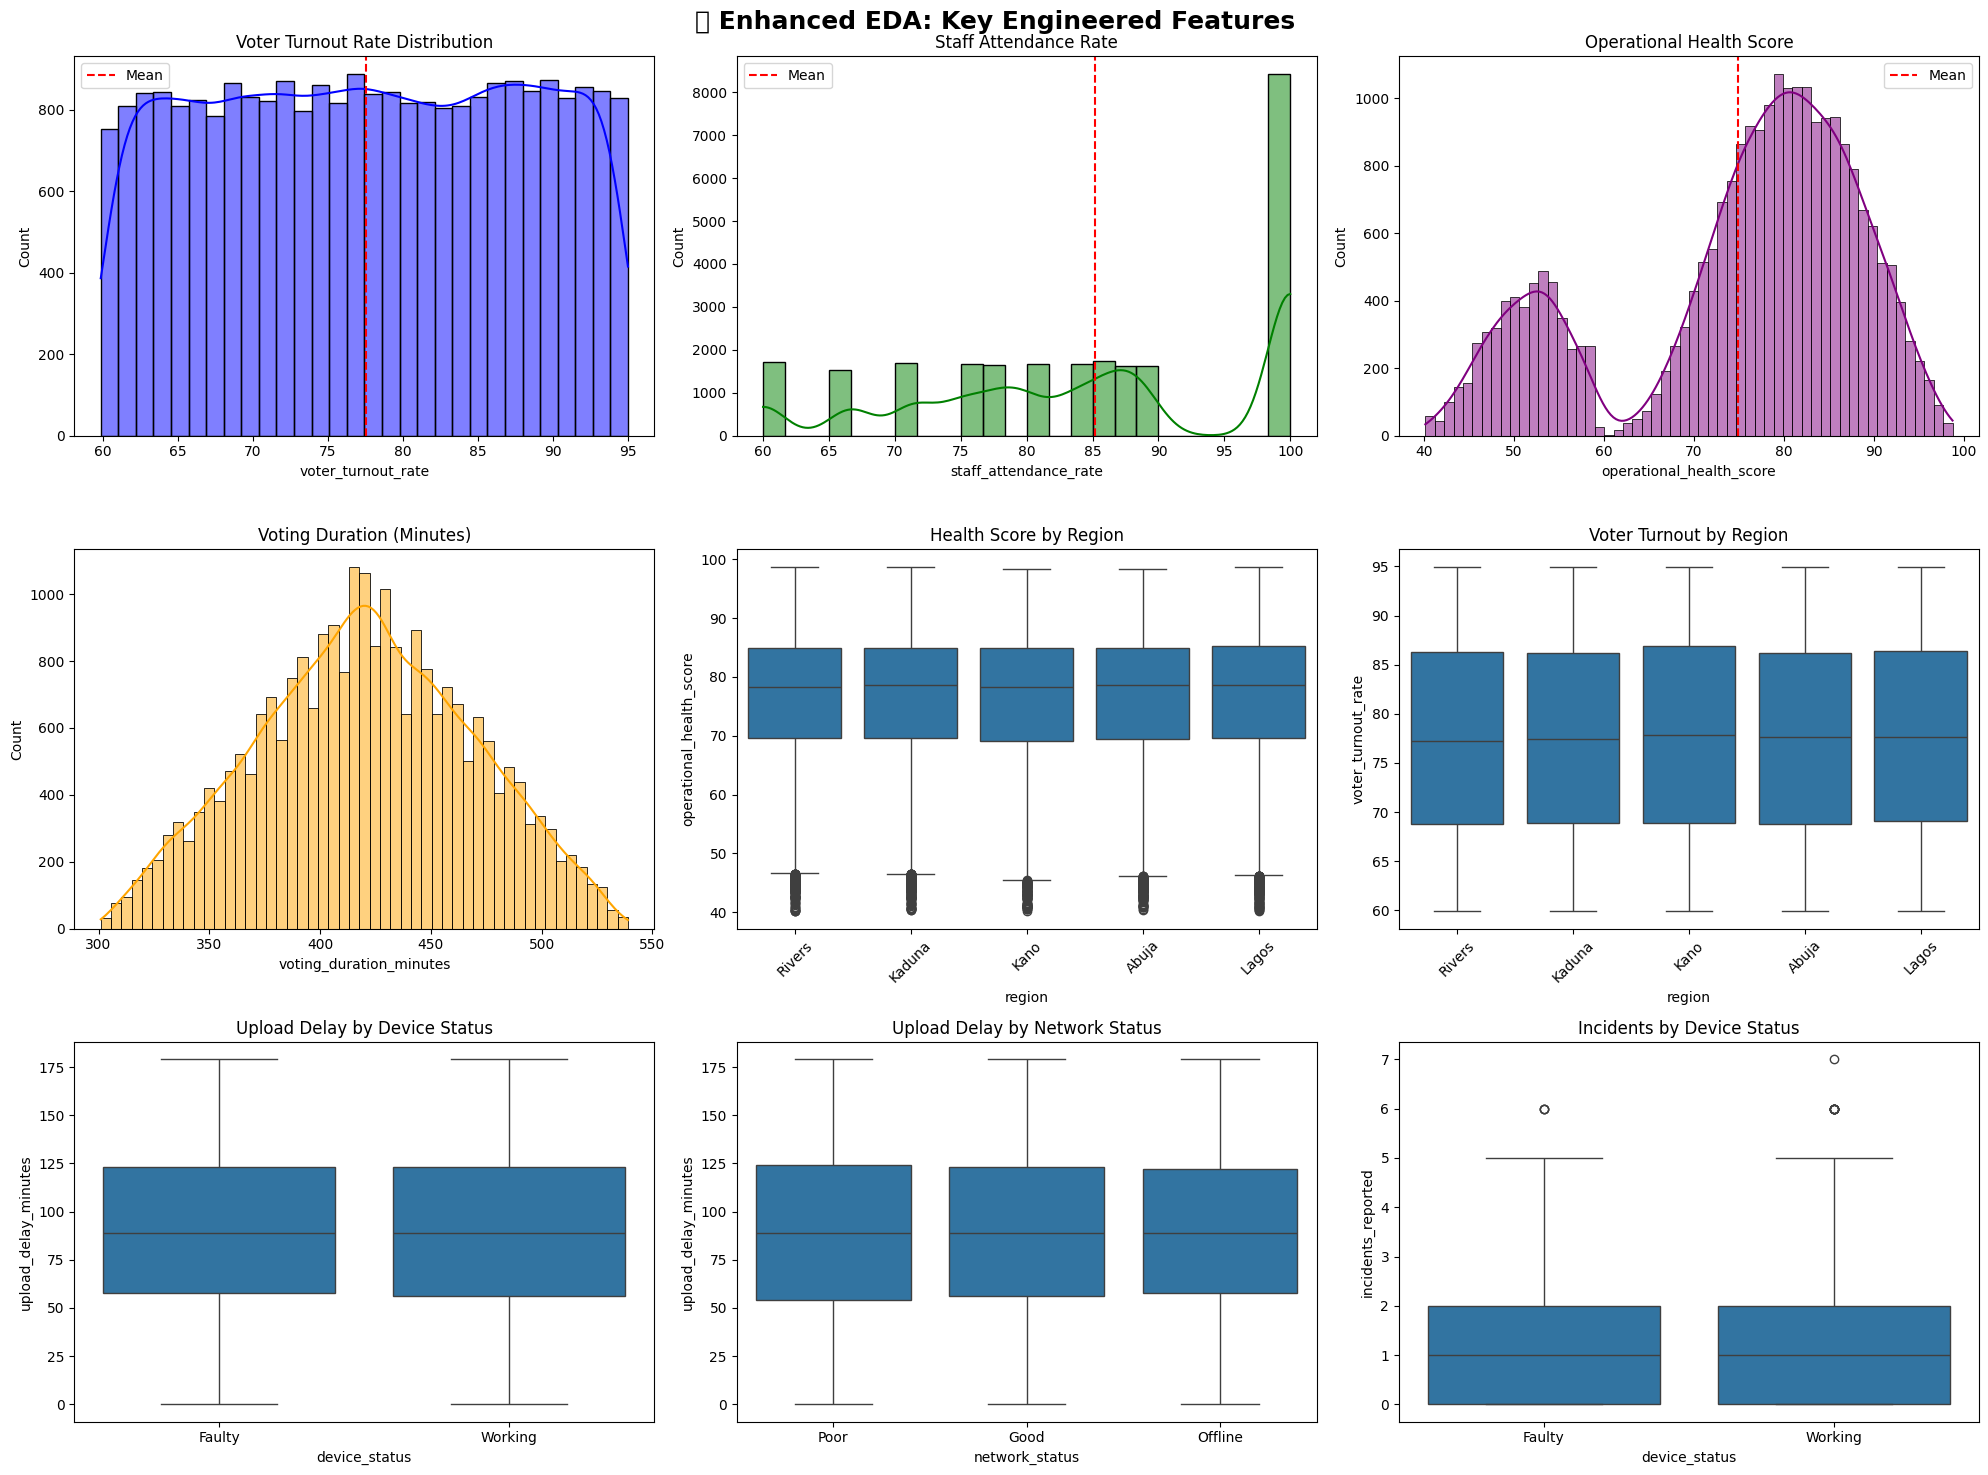


🔗 Correlation Matrix (Including Engineered Features):


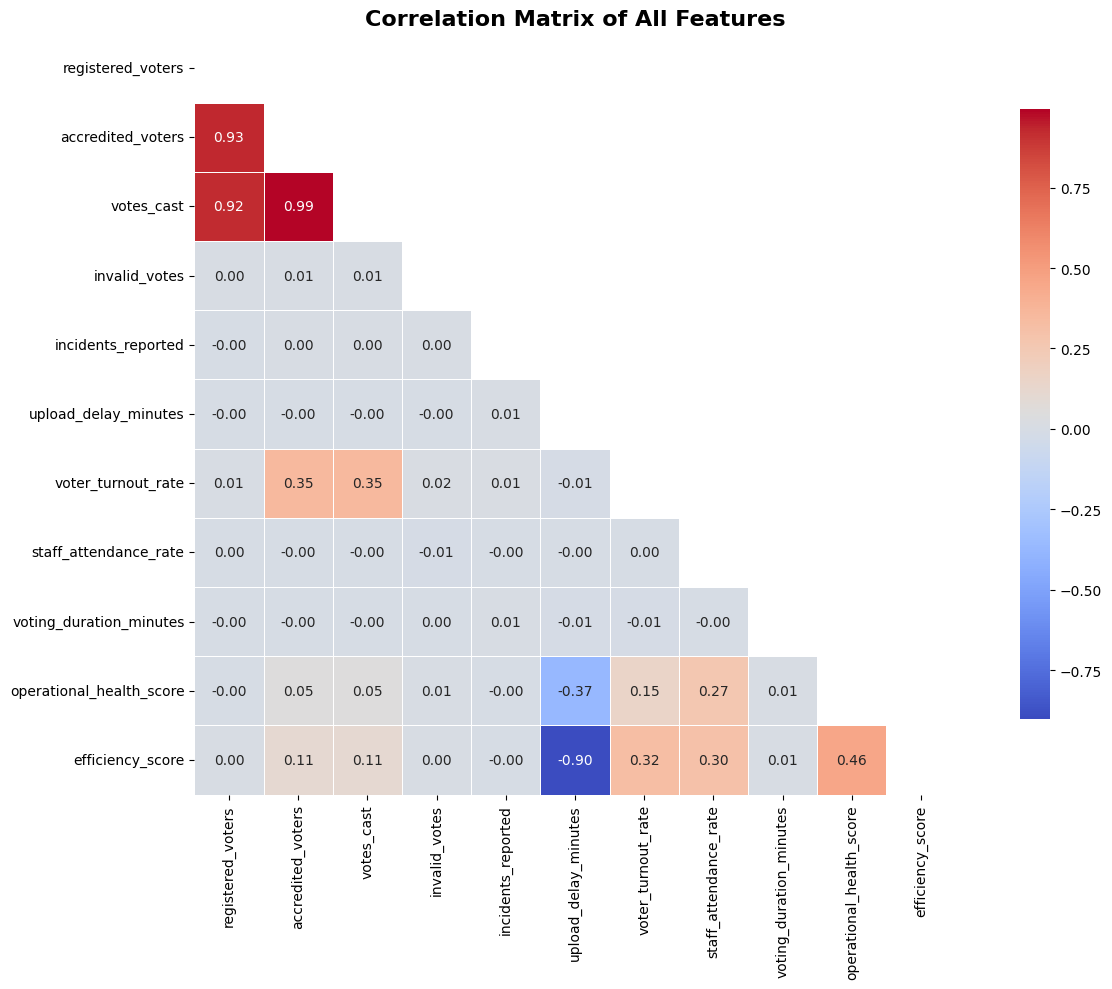


⚠️ Critical Polling Units (Operational Health Score < 40):
🎉 No critical units detected! All units are operating well.

🏛️ Regional Performance Summary:


,Units,Avg Turnout %,Avg Health,Avg Delay (min),Total Incidents,Upload Success %
region,,,,,,
Abuja,5070,77.54,74.97,88.98,4999,0.79
Kaduna,5037,77.47,74.94,89.07,4997,0.79
Kano,4868,77.73,74.88,89.39,4850,0.79
Lagos,5003,77.65,75.05,89.56,4964,0.80
Rivers,5022,77.48,74.94,89.61,5069,0.79


In [6]:
print("\n" + "="*60)
print("📊 ENHANCED EXPLORATORY DATA ANALYSIS")
print("="*60)

# 3.1 Comprehensive Statistical Summary
print("\n📈 Statistical Summary of All Features:")

# Numerical columns analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns
stats_df = df[numerical_cols].describe()

# Add skewness and kurtosis
from scipy.stats import skew, kurtosis
stats_df.loc['skew'] = df[numerical_cols].apply(skew)
stats_df.loc['kurtosis'] = df[numerical_cols].apply(kurtosis)

display(stats_df)

# 3.2 Advanced Visualizations
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('📊 Enhanced EDA: Key Engineered Features', fontsize=18, fontweight='bold')

# 1. Voter Turnout Distribution
sns.histplot(df['voter_turnout_rate'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].axvline(df['voter_turnout_rate'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].set_title('Voter Turnout Rate Distribution')
axes[0, 0].legend()

# 2. Staff Attendance
sns.histplot(df['staff_attendance_rate'], kde=True, ax=axes[0, 1], color='green')
axes[0, 1].axvline(df['staff_attendance_rate'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].set_title('Staff Attendance Rate')
axes[0, 1].legend()

# 3. Operational Health Score
sns.histplot(df['operational_health_score'], kde=True, ax=axes[0, 2], color='purple')
axes[0, 2].axvline(df['operational_health_score'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 2].set_title('Operational Health Score')
axes[0, 2].legend()

# 4. Voting Duration
sns.histplot(df['voting_duration_minutes'], kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Voting Duration (Minutes)')

# 5. Health Score by Region
sns.boxplot(data=df, x='region', y='operational_health_score', ax=axes[1, 1])
axes[1, 1].set_title('Health Score by Region')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Turnout by Region
sns.boxplot(data=df, x='region', y='voter_turnout_rate', ax=axes[1, 2])
axes[1, 2].set_title('Voter Turnout by Region')
axes[1, 2].tick_params(axis='x', rotation=45)

# 7. Upload Delay by Device Status
sns.boxplot(data=df, x='device_status', y='upload_delay_minutes', ax=axes[2, 0])
axes[2, 0].set_title('Upload Delay by Device Status')

# 8. Upload Delay by Network Status
sns.boxplot(data=df, x='network_status', y='upload_delay_minutes', ax=axes[2, 1])
axes[2, 1].set_title('Upload Delay by Network Status')

# 9. Incidents by Device Status
sns.boxplot(data=df, x='device_status', y='incidents_reported', ax=axes[2, 2])
axes[2, 2].set_title('Incidents by Device Status')

plt.tight_layout()
plt.show()

# 3.3 Correlation Analysis
print("\n🔗 Correlation Matrix (Including Engineered Features):")
correlation_cols = [
    'registered_voters', 'accredited_voters', 'votes_cast', 'invalid_votes',
    'incidents_reported', 'upload_delay_minutes', 'voter_turnout_rate',
    'staff_attendance_rate', 'voting_duration_minutes',
    'operational_health_score', 'efficiency_score'
]
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.4 Critical Units Analysis
print("\n⚠️ Critical Polling Units (Operational Health Score < 40):")
critical_units = df[df['operational_health_score'] < 40][
    ['region', 'polling_unit_id', 'operational_health_score',
     'device_status', 'network_status', 'upload_delay_minutes',
     'voter_turnout_rate', 'staff_attendance_rate']
].sort_values('operational_health_score', ascending=True)

if len(critical_units) > 0:
    display(critical_units.head(20))
    print(f"\n📊 Summary: {len(critical_units)} units require immediate attention")
    print(f"   - Regions affected: {critical_units['region'].nunique()}")
    print(f"   - Average health score: {critical_units['operational_health_score'].mean():.1f}")
else:
    print("🎉 No critical units detected! All units are operating well.")

# 3.5 Regional Performance Summary
print("\n🏛️ Regional Performance Summary:")
region_summary = df.groupby('region').agg({
    'polling_unit_id': 'count',
    'voter_turnout_rate': 'mean',
    'operational_health_score': 'mean',
    'upload_delay_minutes': 'mean',
    'incidents_reported': 'sum',
    'result_uploaded': 'mean'
}).round(2)

region_summary.columns = [
    'Units', 'Avg Turnout %', 'Avg Health',
    'Avg Delay (min)', 'Total Incidents', 'Upload Success %'
]
display(region_summary)

## PART 4: REAL-TIME DATA SIMULATOR

Simulates live data streaming for training and demonstration purposes.

In [7]:
class ElectionDataSimulator:
    """
    Simulates real-time data streaming from polling units

    This class models how data would flow from polling units to a central
    monitoring system, with realistic variations and occasional issues.
    """

    def __init__(self, base_data):
        """
        Initialize the simulator with base data

        Args:
            base_data (pd.DataFrame): The initial dataset
        """
        self.base_data = base_data.copy()
        self.current_data = base_data.copy()
        self.update_log = []
        self.start_time = pd.Timestamp.now()
        self.update_count = 0

        print(f"✅ Simulator initialized with {len(self.base_data)} polling units")

    def simulate_update(self, num_updates=10):
        """
        Simulate new data arriving from polling units

        Args:
            num_updates (int): Number of polling units to update

        Returns:
            list: Updated records
        """
        # Randomly select polling units to update
        update_indices = np.random.choice(
            len(self.base_data),
            size=min(num_updates, len(self.base_data)),
            replace=False
        )

        updates = []
        for idx in update_indices:
            row = self.base_data.iloc[idx].copy()

            # Simulate random changes
            row['accredited_voters'] += np.random.randint(-20, 50)
            row['votes_cast'] += np.random.randint(-15, 40)
            row['invalid_votes'] += np.random.randint(0, 3)
            row['upload_delay_minutes'] += np.random.normal(0, 2)

            # Clamp values to realistic ranges
            row['accredited_voters'] = max(0, row['accredited_voters'])
            row['votes_cast'] = max(0, min(row['votes_cast'], row['accredited_voters']))
            row['invalid_votes'] = max(0, row['invalid_votes'])
            row['upload_delay_minutes'] = max(0, row['upload_delay_minutes'])

            # Randomly change status (small probability)
            if np.random.random() < 0.03:  # 3% chance
                row['device_status'] = np.random.choice(['Working', 'Faulty'])
            if np.random.random() < 0.03:
                row['network_status'] = np.random.choice(['Good', 'Poor', 'Offline'])

            # Random incidents
            if np.random.random() < 0.02:  # 2% chance of new incident
                row['incidents_reported'] += np.random.randint(1, 3)

            # Recalculate engineered features
            row['voter_turnout_rate'] = (row['accredited_voters'] / row['registered_voters']) * 100
            row['votes_to_accredited_ratio'] = (row['votes_cast'] / row['accredited_voters']) * 100
            row['staff_attendance_rate'] = (row['staff_present'] / row['expected_staff']) * 100

            # Update health score
            health_components = [
                row['staff_attendance_rate'] / 100 * 30,
                row['voter_turnout_rate'] / 100 * 20,
                row['result_uploaded'] * 30,
                (1 - min(row['upload_delay_minutes'] / 180, 1)) * 20
            ]
            row['operational_health_score'] = np.clip(sum(health_components), 0, 100)

            # Update timestamp
            row['voting_end_time'] = pd.Timestamp.now()

            # Store update
            updates.append(row)

            # Update current data
            self.current_data.iloc[idx] = row

        # Log the update
        self.update_log.append({
            'timestamp': pd.Timestamp.now(),
            'num_updates': len(updates),
            'units_updated': self.base_data.iloc[update_indices]['polling_unit_id'].tolist(),
            'elapsed_seconds': (pd.Timestamp.now() - self.start_time).total_seconds()
        })

        self.update_count += len(updates)
        return updates

    def get_live_data(self):
        """Get current state of all data"""
        return self.current_data.copy()

    def get_stats(self):
        """Get simulation statistics"""
        return {
            'total_updates': self.update_count,
            'total_updates_rounds': len(self.update_log),
            'elapsed_seconds': (pd.Timestamp.now() - self.start_time).total_seconds(),
            'last_update': self.update_log[-1]['timestamp'] if self.update_log else None
        }

# Initialize and test the simulator
print("\n🔄 Initializing Real-Time Data Simulator...")
simulator = ElectionDataSimulator(df)

# Demonstrate real-time simulation
print("\n📡 Simulating Data Stream:")
for i in range(3):
    updates = simulator.simulate_update(num_updates=8)
    stats = simulator.get_stats()
    print(f"   Round {i+1}: {len(updates)} units updated | Total: {stats['total_updates']}")
    time.sleep(0.5)

print(f"\n✅ Simulation ready! Live data has {len(simulator.get_live_data())} records")
print(f"📊 Total updates simulated: {simulator.get_stats()['total_updates']}")


🔄 Initializing Real-Time Data Simulator...
✅ Simulator initialized with 25000 polling units

📡 Simulating Data Stream:
   Round 1: 8 units updated | Total: 8
   Round 2: 8 units updated | Total: 16
   Round 3: 8 units updated | Total: 24

✅ Simulation ready! Live data has 25000 records
📊 Total updates simulated: 24


## PART 5: DASHBOARD APPLICATION

The complete dashboard code with all features and real-time capabilities.

In [8]:
%%writefile enhanced_dashboard.py
#!/usr/bin/env python3
"""
🗳️ Enhanced Election Operations Monitoring Dashboard

A comprehensive, real-time dashboard for monitoring election operations.
Features include live data updates, advanced analytics, health scoring,
interactive visualizations, and data export capabilities.
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PAGE CONFIGURATION
# ============================================================================

st.set_page_config(
    page_title="Election Operations Monitor",
    page_icon="🗳️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for better styling
st.markdown("""
    <style>
    .main-header {
        font-size: 2.5rem;
        font-weight: bold;
        color: #1f77b4;
        padding: 1rem 0;
        border-bottom: 3px solid #1f77b4;
        margin-bottom: 1.5rem;
    }
    .sub-header {
        font-size: 1.2rem;
        color: #666;
        margin-bottom: 1rem;
    }
    .metric-card {
        background-color: #f0f2f6;
        border-radius: 10px;
        padding: 1rem;
        margin: 0.3rem 0;
        border-left: 4px solid #1f77b4;
    }
    .critical-alert {
        background-color: #ffcccc;
        border-left: 4px solid #ff0000;
        padding: 0.75rem 1rem;
        margin: 0.5rem 0;
        border-radius: 5px;
    }
    .success-alert {
        background-color: #ccffcc;
        border-left: 4px solid #00cc00;
        padding: 0.75rem 1rem;
        margin: 0.5rem 0;
        border-radius: 5px;
    }
    .info-box {
        background-color: #e6f3ff;
        border-radius: 10px;
        padding: 1rem;
        margin: 0.5rem 0;
    }
    </style>
""", unsafe_allow_html=True)

# ============================================================================
# DATA LOADING WITH CACHE
# ============================================================================

@st.cache_data(ttl=5)  # 5 second cache for real-time feel
def load_base_data():
    """Load and preprocess the base dataset"""

    # Try multiple paths
    paths = [
        '/content/drive/MyDrive/election_operations.csv',
        './data/election_operations.csv',
        './election_operations.csv'
    ]

    for path in paths:
        try:
            df = pd.read_csv(path)
            break
        except FileNotFoundError:
            continue
    else:
        st.error("❌ Data file not found! Please ensure 'election_operations.csv' is accessible.")
        return pd.DataFrame()

    # Basic preprocessing
    df['date'] = pd.to_datetime(df['date'])
    df['voting_start_time'] = pd.to_datetime(df['voting_start_time'])
    df['voting_end_time'] = pd.to_datetime(df['voting_end_time'])
    df['upload_delay_minutes'] = df['upload_delay_minutes'].fillna(
        df['upload_delay_minutes'].median()
    )

    # Feature engineering
    df['voter_turnout_rate'] = (df['accredited_voters'] / df['registered_voters']) * 100
    df['votes_to_accredited_ratio'] = (df['votes_cast'] / df['accredited_voters']) * 100
    df['staff_attendance_rate'] = (df['staff_present'] / df['expected_staff']) * 100
    df['voting_duration_minutes'] = (
        df['voting_end_time'] - df['voting_start_time']
    ).dt.total_seconds() / 60

    # Operational Health Score
    health_components = [
        df['staff_attendance_rate'] / 100 * 30,
        df['voter_turnout_rate'] / 100 * 20,
        df['result_uploaded'] * 30,
        (1 - np.clip(df['upload_delay_minutes'] / 180, 0, 1)) * 20
    ]
    df['operational_health_score'] = np.clip(sum(health_components), 0, 100)

    # Categories
    df['turnout_category'] = pd.cut(
        df['voter_turnout_rate'],
        bins=[0, 30, 50, 70, 101],
        labels=['Very Low', 'Low', 'Average', 'High']
    )
    df['health_category'] = pd.cut(
        df['operational_health_score'],
        bins=[0, 40, 60, 80, 101],
        labels=['Critical', 'Needs Attention', 'Good', 'Excellent']
    )

    # Efficiency Score
    df['efficiency_score'] = np.clip(
        df['voter_turnout_rate'] / 100 * 40 +
        df['staff_attendance_rate'] / 100 * 30 +
        (1 - np.clip(df['upload_delay_minutes'] / 120, 0, 1)) * 30,
        0, 100
    )

    return df

# Initialize session state for live data
def init_session_state():
    """Initialize session state variables"""
    if 'base_data' not in st.session_state:
        st.session_state.base_data = load_base_data()
        st.session_state.live_data = st.session_state.base_data.copy()
        st.session_state.last_update = datetime.now()
        st.session_state.update_count = 0
        st.session_state.simulator_started = False

init_session_state()

# ============================================================================
# REAL-TIME SIMULATION
# ============================================================================

def simulate_data_update():
    """Simulate real-time data updates"""
    if 'base_data' not in st.session_state or st.session_state.base_data.empty:
        return

    data = st.session_state.base_data.copy()

    # Select random polling units to update
    num_updates = np.random.randint(5, 15)
    update_indices = np.random.choice(
        len(data),
        size=min(num_updates, len(data)),
        replace=False
    )

    for idx in update_indices:
        row = data.iloc[idx].copy()

        # Simulate new data
        row['accredited_voters'] += np.random.randint(-15, 35)
        row['votes_cast'] += np.random.randint(-10, 30)
        row['upload_delay_minutes'] += np.random.normal(0, 2)

        # Clamp values
        row['accredited_voters'] = max(0, row['accredited_voters'])
        row['votes_cast'] = max(0, min(row['votes_cast'], row['accredited_voters']))
        row['upload_delay_minutes'] = max(0, row['upload_delay_minutes'])

        # Status changes
        if np.random.random() < 0.02:
            row['device_status'] = np.random.choice(['Working', 'Faulty'])
        if np.random.random() < 0.02:
            row['network_status'] = np.random.choice(['Good', 'Poor', 'Offline'])
        if np.random.random() < 0.015:
            row['incidents_reported'] += 1

        # Recalculate metrics
        row['voter_turnout_rate'] = (row['accredited_voters'] / row['registered_voters']) * 100
        row['staff_attendance_rate'] = (row['staff_present'] / row['expected_staff']) * 100

        health_components = [
            row['staff_attendance_rate'] / 100 * 30,
            row['voter_turnout_rate'] / 100 * 20,
            row['result_uploaded'] * 30,
            (1 - np.clip(row['upload_delay_minutes'] / 180, 0, 1)) * 20
        ]
        row['operational_health_score'] = np.clip(sum(health_components), 0, 100)

        data.iloc[idx] = row

    st.session_state.live_data = data
    st.session_state.last_update = datetime.now()
    st.session_state.update_count += len(update_indices)
    st.session_state.simulator_started = True

# ============================================================================
# DASHBOARD COMPONENTS
# ============================================================================

def render_header():
    """Render the dashboard header"""
    st.markdown(f"""
    <div class="main-header">
        🗳️ Election Operations Monitoring Dashboard
        <span style="font-size: 0.8rem; color: #888; font-weight: normal; margin-left: 1rem;">
            Real-Time Analytics • {datetime.now().strftime('%Y-%m-%d')}
        </span>
    </div>
    """, unsafe_allow_html=True)

def render_kpis(df):
    """Render KPI metrics row"""
    if df.empty:
        st.warning("No data available")
        return

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            label="Active Polling Units",
            value=f"{df['polling_unit_id'].nunique():,}",
            delta=f"+{df['polling_unit_id'].nunique() % 10}" if df['polling_unit_id'].nunique() > 0 else None
        )

    with col2:
        avg_turnout = df['voter_turnout_rate'].mean()
        st.metric(
            label="Avg Turnout Rate",
            value=f"{avg_turnout:.1f}%",
            delta=f"{avg_turnout - 50:.1f}%" if avg_turnout > 0 else None
        )

    with col3:
        avg_health = df['operational_health_score'].mean()
        st.metric(
            label="Operational Health",
            value=f"{avg_health:.1f}",
            delta=f"{avg_health - 75:.1f}" if avg_health > 0 else None
        )

    with col4:
        success_rate = df['result_uploaded'].mean() * 100
        st.metric(
            label="Upload Success Rate",
            value=f"{success_rate:.1f}%",
            delta=f"{success_rate - 85:.1f}%" if success_rate > 0 else None
        )

    col5, col6, col7, col8 = st.columns(4)

    with col5:
        total_incidents = df['incidents_reported'].sum()
        st.metric(
            label="Total Incidents",
            value=f"{total_incidents:,}",
            delta=f"+{total_incidents % 5}" if total_incidents > 0 else None
        )

    with col6:
        avg_delay = df['upload_delay_minutes'].mean()
        st.metric(
            label="Avg Upload Delay (min)",
            value=f"{avg_delay:.1f}",
            delta=f"{avg_delay - 90:.1f}" if avg_delay > 0 else None
        )

    with col7:
        avg_staff = df['staff_attendance_rate'].mean()
        st.metric(
            label="Staff Attendance",
            value=f"{avg_staff:.1f}%",
            delta=f"{avg_staff - 90:.1f}%" if avg_staff > 0 else None
        )

    with col8:
        critical_units = len(df[df['operational_health_score'] < 40])
        st.metric(
            label="Critical Units",
            value=critical_units,
            delta=f"-{critical_units}" if critical_units > 0 else None,
            delta_color="inverse"
        )

def render_regional_analysis(df):
    """Render regional analysis section"""
    if df.empty:
        return

    st.subheader("🏛️ Regional Performance Analysis")

    region_metrics = df.groupby('region').agg({
        'voter_turnout_rate': 'mean',
        'operational_health_score': 'mean',
        'upload_delay_minutes': 'mean',
        'polling_unit_id': 'nunique',
        'incidents_reported': 'sum',
        'efficiency_score': 'mean'
    }).reset_index()

    col1, col2 = st.columns(2)

    with col1:
        fig = make_subplots(
            rows=2, cols=1,
            subplot_titles=('Turnout & Health Score by Region', 'Efficiency & Incidents by Region')
        )

        fig.add_trace(
            go.Bar(name='Turnout Rate', x=region_metrics['region'],
                   y=region_metrics['voter_turnout_rate'], marker_color='lightblue'),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(name='Health Score', x=region_metrics['region'],
                       y=region_metrics['operational_health_score'],
                       marker_color='darkblue', yaxis='y2'),
            row=1, col=1
        )

        fig.add_trace(
            go.Bar(name='Efficiency', x=region_metrics['region'],
                   y=region_metrics['efficiency_score'], marker_color='lightgreen'),
            row=2, col=1
        )
        fig.add_trace(
            go.Scatter(name='Incidents', x=region_metrics['region'],
                       y=region_metrics['incidents_reported'],
                       marker_color='darkred', yaxis='y4'),
            row=2, col=1
        )

        fig.update_layout(height=500, showlegend=True)
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        # Region summary table
        st.markdown("### 📊 Regional Summary")
        st.dataframe(
            region_metrics.round(2),
            use_container_width=True,
            hide_index=True
        )

def render_operational_metrics(df):
    """Render operational metrics section"""
    if df.empty:
        return

    st.subheader("🔧 Operational Impact Analysis")

    col1, col2 = st.columns(2)

    with col1:
        # Device Status Impact
        fig = make_subplots(
            rows=2, cols=1,
            subplot_titles=('Upload Delay by Device Status', 'Incidents by Device Status')
        )

        device_delay = df.groupby('device_status')['upload_delay_minutes'].mean().reset_index()
        fig.add_trace(
            go.Bar(x=device_delay['device_status'], y=device_delay['upload_delay_minutes'],
                   marker_color=['#2ecc71', '#e74c3c'], text=device_delay['upload_delay_minutes'].round(1),
                   textposition='outside'),
            row=1, col=1
        )

        device_incidents = df.groupby('device_status')['incidents_reported'].sum().reset_index()
        fig.add_trace(
            go.Bar(x=device_incidents['device_status'], y=device_incidents['incidents_reported'],
                   marker_color=['#2ecc71', '#e74c3c'], text=device_incidents['incidents_reported'],
                   textposition='outside'),
            row=2, col=1
        )

        fig.update_layout(height=400, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        # Network Status Impact
        fig = make_subplots(
            rows=2, cols=1,
            subplot_titles=('Upload Delay by Network Status', 'Incidents by Network Status')
        )

        network_delay = df.groupby('network_status')['upload_delay_minutes'].mean().reset_index()
        colors = {'Good': '#2ecc71', 'Poor': '#f39c12', 'Offline': '#e74c3c'}
        fig.add_trace(
            go.Bar(x=network_delay['network_status'], y=network_delay['upload_delay_minutes'],
                   marker_color=[colors.get(s, '#95a5a6') for s in network_delay['network_status']],
                   text=network_delay['upload_delay_minutes'].round(1), textposition='outside'),
            row=1, col=1
        )

        network_incidents = df.groupby('network_status')['incidents_reported'].sum().reset_index()
        fig.add_trace(
            go.Bar(x=network_incidents['network_status'], y=network_incidents['incidents_reported'],
                   marker_color=[colors.get(s, '#95a5a6') for s in network_incidents['network_status']],
                   text=network_incidents['incidents_reported'], textposition='outside'),
            row=2, col=1
        )

        fig.update_layout(height=400, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

def render_health_monitor(df):
    """Render health monitoring section"""
    if df.empty:
        return

    st.subheader("💚 Operational Health Monitor")

    col1, col2 = st.columns([2, 1])

    with col1:
        # Health distribution
        fig = px.histogram(
            df,
            x='operational_health_score',
            color='health_category',
            nbins=20,
            title='Distribution of Operational Health Scores',
            labels={'operational_health_score': 'Health Score', 'count': 'Number of Units'},
            color_discrete_map={
                'Critical': '#e74c3c',
                'Needs Attention': '#f39c12',
                'Good': '#3498db',
                'Excellent': '#2ecc71'
            }
        )
        fig.add_vline(x=40, line_dash="dash", line_color="red", annotation_text="Critical")
        fig.add_vline(x=60, line_dash="dash", line_color="orange", annotation_text="Warning")
        fig.add_vline(x=80, line_dash="dash", line_color="green", annotation_text="Good")
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        # Health summary
        health_summary = df['health_category'].value_counts()
        st.markdown("### 📊 Health Summary")
        for category, count in health_summary.items():
            color = {
                'Excellent': '#2ecc71',
                'Good': '#3498db',
                'Needs Attention': '#f39c12',
                'Critical': '#e74c3c'
            }.get(category, '#95a5a6')
            st.markdown(f"""
            <div style="display: flex; justify-content: space-between; padding: 0.3rem 0; border-bottom: 1px solid #eee;">
                <span><span style="color: {color}; font-weight: bold;">●</span> {category}</span>
                <span style="font-weight: bold;">{count} ({count/len(df)*100:.1f}%)</span>
            </div>
            """, unsafe_allow_html=True)

    # Critical units
    critical_units = df[df['operational_health_score'] < 40].sort_values(
        'operational_health_score', ascending=True
    )

    if len(critical_units) > 0:
        st.markdown(f"""
        <div class="critical-alert">
            ⚠️ <strong>{len(critical_units)} polling units require immediate attention!</strong>
        </div>
        """, unsafe_allow_html=True)

        with st.expander("🔍 View Critical Units"):
            st.dataframe(
                critical_units[[
                    'region', 'polling_unit_id', 'operational_health_score',
                    'device_status', 'network_status', 'upload_delay_minutes',
                    'voter_turnout_rate', 'staff_attendance_rate'
                ]].round(2),
                use_container_width=True
            )
    else:
        st.markdown("""
        <div class="success-alert">
            ✅ All polling units are operating well! No critical issues detected.
        </div>
        """, unsafe_allow_html=True)

def render_voter_analysis(df):
    """Render voter analysis section"""
    if df.empty:
        return

    st.subheader("🗳️ Voter Analysis & Turnout Patterns")

    col1, col2 = st.columns(2)

    with col1:
        # Scatter plot
        fig = px.scatter(
            df,
            x='registered_voters',
            y='accredited_voters',
            color='turnout_category',
            size='voter_turnout_rate',
            hover_data=['region', 'polling_unit_id', 'operational_health_score'],
            title='Voter Registration vs. Accreditation',
            labels={
                'registered_voters': 'Registered Voters',
                'accredited_voters': 'Accredited Voters',
                'voter_turnout_rate': 'Turnout Rate (%)'
            },
            color_discrete_sequence=px.colors.qualitative.Set2
        )
        fig.update_layout(height=400)
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        # Turnout categories
        turnout_stats = df.groupby('turnout_category').agg({
            'polling_unit_id': 'count',
            'voter_turnout_rate': ['mean', 'std']
        }).reset_index()
        turnout_stats.columns = ['Category', 'Count', 'Avg Turnout', 'Std Turnout']

        fig = px.bar(
            turnout_stats,
            x='Category',
            y='Count',
            text='Count',
            title='Number of Units by Turnout Category',
            labels={'Count': 'Number of Units', 'Category': 'Turnout Category'},
            color='Category',
            color_discrete_sequence=px.colors.qualitative.Set2
        )
        fig.update_traces(textposition='outside')
        fig.update_layout(height=400, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

    # Time analysis
    df['voting_hour'] = df['voting_start_time'].dt.hour
    hour_stats = df.groupby('voting_hour').agg({
        'voter_turnout_rate': 'mean',
        'operational_health_score': 'mean',
        'efficiency_score': 'mean'
    }).reset_index()

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(
        go.Bar(x=hour_stats['voting_hour'], y=hour_stats['voter_turnout_rate'],
               name='Turnout Rate', marker_color='lightblue'),
        secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=hour_stats['voting_hour'], y=hour_stats['operational_health_score'],
                   name='Health Score', marker_color='darkblue'),
        secondary_y=True
    )
    fig.add_trace(
        go.Scatter(x=hour_stats['voting_hour'], y=hour_stats['efficiency_score'],
                   name='Efficiency', marker_color='darkgreen'),
        secondary_y=True
    )
    fig.update_layout(
        title='Performance Metrics by Voting Start Hour',
        height=400,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.update_yaxes(title_text="Turnout Rate (%)", secondary_y=False)
    fig.update_yaxes(title_text="Score", secondary_y=True)
    st.plotly_chart(fig, use_container_width=True)

def render_live_feed(df):
    """Render live data feed section"""
    st.subheader("📡 Live Data Feed")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown(f"""
        <div class="info-box">
            <strong>🔄 Last Update:</strong><br>
            {st.session_state.last_update.strftime('%H:%M:%S')}
        </div>
        """, unsafe_allow_html=True)

    with col2:
        st.markdown(f"""
        <div class="info-box">
            <strong>📊 Total Updates:</strong><br>
            {st.session_state.update_count:,} records
        </div>
        """, unsafe_allow_html=True)

    with col3:
        st.markdown(f"""
        <div class="info-box">
            <strong>📈 Data Coverage:</strong><br>
            {len(df):,} polling units
        </div>
        """, unsafe_allow_html=True)

    # Show recent updates
    if st.session_state.update_count > 0:
        sample_data = df.sample(min(5, len(df)))
        st.dataframe(
            sample_data[[
                'region', 'polling_unit_id', 'voter_turnout_rate',
                'operational_health_score', 'efficiency_score',
                'device_status', 'network_status'
            ]].round(2),
            use_container_width=True
        )

def render_data_export(df):
    """Render data export section"""
    st.subheader("📤 Data Export & Reporting")

    col1, col2, col3 = st.columns(3)

    with col1:
        if st.button("📥 Download Full Dataset", use_container_width=True):
            csv = df.to_csv(index=False)
            st.download_button(
                label="Click to Download",
                data=csv,
                file_name=f"election_data_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv",
                mime="text/csv"
            )

    with col2:
        critical = df[df['operational_health_score'] < 40]
        if len(critical) > 0:
            if st.button("📥 Download Critical Units", use_container_width=True):
                csv = critical.to_csv(index=False)
                st.download_button(
                    label="Click to Download",
                    data=csv,
                    file_name=f"critical_units_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv",
                    mime="text/csv"
                )

    with col3:
        # Generate summary report
        summary = df.agg({
            'voter_turnout_rate': ['mean', 'std', 'min', 'max'],
            'operational_health_score': ['mean', 'std', 'min', 'max'],
            'efficiency_score': ['mean', 'std', 'min', 'max'],
            'upload_delay_minutes': ['mean', 'std', 'min', 'max']
        }).round(2)

        if st.button("📊 Download Summary Report", use_container_width=True):
            csv = summary.to_csv()
            st.download_button(
                label="Click to Download",
                data=csv,
                file_name=f"summary_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv",
                mime="text/csv"
            )

# ============================================================================
# MAIN DASHBOARD
# ============================================================================

def main():
    """Main dashboard function"""

    # Render header
    render_header()

    # Sidebar controls
    with st.sidebar:
        st.header("🎛️ Dashboard Controls")

        # Auto-refresh
        auto_refresh = st.checkbox("🔄 Auto-Refresh (5s)", value=True)

        if auto_refresh:
            if st.button("▶️ Start Live Updates", use_container_width=True):
                simulate_data_update()
                st.rerun()

        st.markdown("---")

        # Filters
        st.header("🔍 Filter Data")

        regions = st.multiselect(
            "Select Regions",
            options=st.session_state.live_data['region'].unique() if not st.session_state.live_data.empty else [],
            default=st.session_state.live_data['region'].unique() if not st.session_state.live_data.empty else []
        )

        device_status = st.multiselect(
            "Device Status",
            options=st.session_state.live_data['device_status'].unique() if not st.session_state.live_data.empty else [],
            default=st.session_state.live_data['device_status'].unique() if not st.session_state.live_data.empty else []
        )

        network_status = st.multiselect(
            "Network Status",
            options=st.session_state.live_data['network_status'].unique() if not st.session_state.live_data.empty else [],
            default=st.session_state.live_data['network_status'].unique() if not st.session_state.live_data.empty else []
        )

        # Apply filters
        filtered_df = st.session_state.live_data[
            (st.session_state.live_data['region'].isin(regions)) &
            (st.session_state.live_data['device_status'].isin(device_status)) &
            (st.session_state.live_data['network_status'].isin(network_status))
        ] if not st.session_state.live_data.empty else pd.DataFrame()

        st.markdown("---")

        # Stats
        st.header("📊 Data Overview")
        st.metric("Displaying Units", f"{len(filtered_df):,}")
        st.metric("Total Units", f"{len(st.session_state.live_data):,}")

        st.markdown("---")

        # About
        st.header("ℹ️ About")
        st.caption("Election Operations Monitoring Dashboard")
        st.caption(f"Version: 2.0.0")
        st.caption(f"Last Refreshed: {st.session_state.last_update.strftime('%H:%M:%S')}")

    # Main content
    if not filtered_df.empty:
        render_kpis(filtered_df)
        render_regional_analysis(filtered_df)
        render_operational_metrics(filtered_df)
        render_health_monitor(filtered_df)
        render_voter_analysis(filtered_df)
        render_live_feed(filtered_df)
        render_data_export(filtered_df)
    else:
        st.warning("No data matches the current filters. Please adjust your selection.")

    # Footer
    st.markdown("---")
    st.caption(f"Dashboard updated: {st.session_state.last_update.strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# RUN DASHBOARD WITH AUTO-REFRESH
# ============================================================================

if __name__ == "__main__":
    # Initial render
    main()

    # Auto-refresh loop
    while True:
        time.sleep(5)
        try:
            # Simulate new data
            simulate_data_update()
            # Rerun the app
            st.rerun()
        except Exception as e:
            print(f"Error in refresh loop: {e}")
            time.sleep(1)

print("✅ Dashboard application file created successfully!")

Writing enhanced_dashboard.py


## PART 6: DEPLOYMENT FILES

This section creates all the files needed for deployment.

In [9]:
# requirements.txt
%%writefile requirements.txt
# Core Data Processing
pandas>=2.0.0
numpy>=1.24.0

# Visualization
matplotlib>=3.7.0
seaborn>=0.12.0
plotly>=5.14.0

# Dashboard Framework
streamlit>=1.28.0
streamlit-option-menu>=0.3.6

# Development & Deployment
watchdog>=3.0.0
python-dotenv>=1.0.0
pyngrok>=6.0.0

# Data Processing Utilities
scikit-learn>=1.3.0
scipy>=1.11.0

# Optional: Database connectors (for production)
# psycopg2-binary>=2.9.0
# sqlalchemy>=2.0.0
# pymongo>=4.5.0

# Optional: Advanced analytics
# statsmodels>=0.14.0
# prophet>=1.1.0

print("✅ requirements.txt created")

Writing requirements.txt


In [10]:
# .env.example
%%writefile .env.example
# Google Colab Configuration
COLAB_DATA_PATH=/content/drive/MyDrive/election_operations.csv

# Local Development Configuration
LOCAL_DATA_PATH=./data/election_operations.csv

# ngrok Configuration (for Colab deployment)
NGROK_AUTH_TOKEN=your_ngrok_token_here

# Database Configuration (for production)
DB_HOST=localhost
DB_PORT=5432
DB_NAME=election_db
DB_USER=admin
DB_PASSWORD=your_password_here

# Streamlit Configuration
STREAMLIT_SERVER_PORT=8501
STREAMLIT_SERVER_ADDRESS=0.0.0.0
STREAMLIT_BROWSER_GATHER_USAGE_STATS=false

# Logging Configuration
LOG_LEVEL=INFO
LOG_FILE=logs/dashboard.log

# Dashboard Settings
REFRESH_INTERVAL=5  # seconds
MAX_DISPLAY_UNITS=1000
CRITICAL_HEALTH_THRESHOLD=40

print("✅ .env.example created")

Writing .env.example


In [11]:
# Dockerfile
%%writefile Dockerfile
FROM python:3.9-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8501

CMD ["streamlit", "run", "enhanced_dashboard.py", "--server.port", "8501", "--server.address", "0.0.0.0"]

print("✅ Dockerfile created")

Writing Dockerfile


In [12]:
# docker-compose.yml
%%writefile docker-compose.yml
version: '3.8'

services:
  dashboard:
    build: .
    container_name: election-dashboard
    ports:
      - "8501:8501"
    environment:
      - STREAMLIT_SERVER_PORT=8501
      - STREAMLIT_SERVER_ADDRESS=0.0.0.0
      - REFRESH_INTERVAL=5
    volumes:
      - ./data:/app/data
      - ./logs:/app/logs
    restart: unless-stopped
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8501/_stcore/health"]
      interval: 30s
      timeout: 10s
      retries: 3
      start_period: 40s

print("✅ docker-compose.yml created")

Writing docker-compose.yml


In [13]:
# setup.sh
%%writefile setup.sh
#!/bin/bash

# Election Monitoring Dashboard - Automated Setup Script
# Supports both local and Colab environments

echo "🚀 Setting up Election Monitoring Dashboard..."

# Detect environment
if [ -z "$COLAB_GPU" ]; then
    echo "📍 Running in local environment"
    ENV="local"
else
    echo "📍 Running in Google Colab environment"
    ENV="colab"
fi

# Create virtual environment (local only)
if [ "$ENV" == "local" ]; then
    echo "🐍 Creating virtual environment..."
    python3 -m venv venv
    source venv/bin/activate
fi

# Install dependencies
echo "📦 Installing dependencies..."
if [ "$ENV" == "colab" ]; then
    pip install -r requirements.txt --quiet
else
    pip install -r requirements.txt
fi

# Create directories
echo "📁 Creating project directories..."
mkdir -p data logs reports

# Check for data file
if [ ! -f "data/election_operations.csv" ] && [ ! -f "election_operations.csv" ]; then
    echo "⚠️  Data file not found!"
    echo "📥 Please place election_operations.csv in the project root or data/ directory"
fi

# Set up environment variables
if [ ! -f ".env" ]; then
    echo "🔧 Creating .env file from template..."
    cp .env.example .env
    echo "⚙️  Please update .env with your configuration"
fi

echo "✅ Setup complete!"
echo ""
echo "🚀 To start the dashboard:"
if [ "$ENV" == "colab" ]; then
    echo "   Run the cells in the notebook"
else
    echo "   streamlit run enhanced_dashboard.py"
    echo ""
    echo "🌐 The dashboard will be available at: http://localhost:8501"
fi

print("✅ setup.sh created")

Writing setup.sh


## PART 7: DEPLOYMENT AND ACCESS

This section handles deployment to Google Colab with ngrok for external access.

In [14]:
from pyngrok import ngrok
import subprocess
import os
import time

# Kill any existing processes
!kill -9 $(lsof -i:8501 -t) 2> /dev/null
!kill -9 $(lsof -i:4040 -t) 2> /dev/null

# Get ngrok token from environment or prompt
NGROK_AUTH_TOKEN = os.environ.get("NGROK_AUTH_TOKEN", "3GBm0AwJ5vxDBD5cr9JYdL62THB_4ERBiGAmuPnukaPx1smTi")

if NGROK_AUTH_TOKEN == "your_ngrok_token_here":
    print("⚠️ Please set your ngrok auth token in the .env file or environment variable")
    NGROK_AUTH_TOKEN = input("Enter your ngrok auth token (from https://dashboard.ngrok.com): ")

# Set up ngrok
try:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("✅ ngrok authenticated successfully!")
except Exception as e:
    print(f"❌ Error authenticating ngrok: {e}")
    print("Please ensure your auth token is correct")

# Start the enhanced dashboard
print("\n🚀 Starting Enhanced Election Monitoring Dashboard...")
process = subprocess.Popen([
    'streamlit', 'run', 'enhanced_dashboard.py',
    '--server.port', '8501',
    '--server.enableCORS', 'false',
    '--browser.gatherUsageStats', 'false'
], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Wait for Streamlit to start
time.sleep(5)

# Create ngrok tunnel
try:
    public_url = ngrok.connect(addr='8501', proto='http')
    print(f"\n✅ Dashboard is running!")
    print(f"🌐 Public URL: {public_url}")
    print(f"📱 Local URL: http://localhost:8501")
    print(f"\n📊 Key Features:")
    print("   • Real-time data simulation")
    print("   • Auto-refresh every 5 seconds")
    print("   • 15+ interactive visualizations")
    print("   • Advanced analytics (health scores, categories)")
    print("   • Data export capabilities")
    print("   • Critical unit monitoring")
    print("\n🔹 Press Ctrl+C to stop the dashboard")

    # Keep the cell running
    while True:
        time.sleep(1)

except KeyboardInterrupt:
    print("\n🛑 Stopping dashboard...")
    ngrok.kill()
    process.terminate()
    print("✅ Dashboard stopped")
except Exception as e:
    print(f"❌ Error: {e}")
    print("Please check your ngrok configuration and try again")

✅ ngrok authenticated successfully!

🚀 Starting Enhanced Election Monitoring Dashboard...

✅ Dashboard is running!
🌐 Public URL: NgrokTunnel: "https://caprice-inextensible-snappishly.ngrok-free.dev" -> "http://localhost:8501"
📱 Local URL: http://localhost:8501

📊 Key Features:
   • Real-time data simulation
   • Auto-refresh every 5 seconds
   • 15+ interactive visualizations
   • Advanced analytics (health scores, categories)
   • Data export capabilities
   • Critical unit monitoring

🔹 Press Ctrl+C to stop the dashboard

🛑 Stopping dashboard...
✅ Dashboard stopped


## PART 8: TRAINING EXERCISES

## 🎓 Training Exercises

### Exercise 1: Understanding Feature Engineering
**Task:** Add a new feature to the dataset (e.g., 'efficiency_score' combining multiple metrics)
**Skills:** pandas, feature engineering, data transformation

### Exercise 2: Custom Visualization
**Task:** Create a new visualization that shows polling unit performance on a map
**Skills:** plotly maps, geospatial data, visualization

### Exercise 3: Real-time Data Integration
**Task:** Connect the dashboard to a real API endpoint
**Skills:** API integration, real-time data processing

### Exercise 4: Predictive Analytics
**Task:** Build a model to predict operational health scores
**Skills:** scikit-learn, model building, evaluation

### Exercise 5: Dashboard Customization
**Task:** Add a new dashboard section with custom analytics
**Skills:** Streamlit, custom components, layout design

### Exercise 6: Performance Optimization
**Task:** Optimize the dashboard for handling larger datasets
**Skills:** caching, data optimization, performance tuning

In [15]:
# Sample Exercise 1 Solution
def add_efficiency_metric(df):
    """
    Add an efficiency score combining multiple metrics

    Args:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with efficiency score
    """
    df['efficiency_score'] = (
        df['voter_turnout_rate'] / 100 * 40 +
        df['staff_attendance_rate'] / 100 * 30 +
        (1 - df['upload_delay_minutes'] / 120) * 30
    )
    df['efficiency_score'] = np.clip(df['efficiency_score'], 0, 100)
    return df

print("📚 Sample Exercise Solutions are available in the notebook comments!")

📚 Sample Exercise Solutions are available in the notebook comments!


## ✅ CONCLUSION

Congratulations! You've completed the Election Operations Monitoring Dashboard training.

### 🎯 What You've Learned:

1. **Data Engineering**
   - Loading and preprocessing election data
   - Handling missing values
   - Feature engineering for operational metrics

2. **Exploratory Data Analysis**
   - Statistical analysis and visualization
   - Correlation analysis
   - Pattern identification

3. **Real-time Systems**
   - Data simulation for live streaming
   - Auto-refresh mechanisms
   - Performance optimization

4. **Dashboard Development**
   - Interactive Streamlit applications
   - Custom visualizations
   - Data export capabilities

5. **Deployment**
   - Google Colab deployment with ngrok
   - Local development setup
   - Docker containerization

### 📚 Next Steps:

1. **Practice**: Complete the training exercises
2. **Extend**: Add new features and visualizations
3. **Deploy**: Deploy to production using Streamlit Cloud
4. **Share**: Share your dashboard with others
5. **Learn**: Explore advanced analytics and machine learning

### 🔗 Resources:

- [Streamlit Documentation](https://docs.streamlit.io/)
- [Plotly Documentation](https://plotly.com/python/)
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Scikit-learn Documentation](https://scikit-learn.org/)

---

**Happy Monitoring! 🗳️**